In [4]:
!pip install pandas

In [2]:
import pandas as pd
df = pd.read_csv("store_customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [12]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Gender'].unique()
df['Gender'].value_counts()

Gender
F    522
M    475
Name: count, dtype: int64

In [15]:
df.drop("CustomerID", axis=1, inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  997 non-null    str    
 1   Age                     994 non-null    float64
 2   Annual Income (k$)      996 non-null    float64
 3   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), str(1)
memory usage: 31.4 KB


In [18]:
df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_23528\1864180945.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean(), inplace=True)


0       59.9
1       48.4
2       70.5
3       81.1
4       42.1
       ...  
995    133.3
996     82.6
997     67.7
998     45.7
999    107.8
Name: Annual Income (k$), Length: 1000, dtype: float64

In [19]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_23528\3657246551.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


0      M
1      M
2      F
3      F
4      F
      ..
995    M
996    M
997    F
998    F
999    M
Name: Gender, Length: 1000, dtype: str

In [22]:
#Convert Categorical Data into Numeric
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [23]:
# CHEAK OUTLIERS
import matplotlib.pyplot as plt

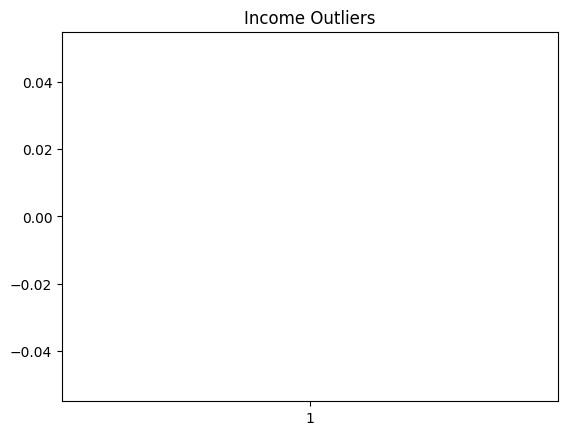

In [24]:
plt.boxplot(df['Annual Income (k$)'])
plt.title("Income Outliers")
plt.show()

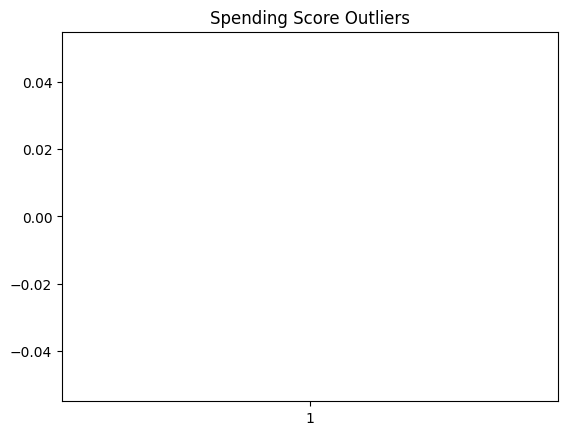

In [25]:
plt.boxplot(df['Spending Score (1-100)'])
plt.title("Spending Score Outliers")
plt.show()

In [26]:
# FINAL CHEAK
df.info()
df.isnull().sum()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  0 non-null      float64
 1   Age                     994 non-null    float64
 2   Annual Income (k$)      996 non-null    float64
 3   Spending Score (1-100)  994 non-null    float64
dtypes: float64(4)
memory usage: 31.4 KB


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,NaN,39.0,59.9,58.0
1,NaN,34.0,48.4,37.0
2,NaN,40.0,70.5,26.0
3,NaN,47.0,81.1,30.0
4,NaN,33.0,42.1,58.0


In [10]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [20]:
# FEATURE saclling 
!pip install scikit-learn


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 3.5 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 3.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 3.0 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.0 MB 3.0 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 3.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 3.0 MB/s eta 0:00:01
   ------------------------------

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# find best K using elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [25]:
#find and remove NaN values
X.isnull().sum()
X = X.dropna()
X = X.fillna(X.mean())

In [26]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

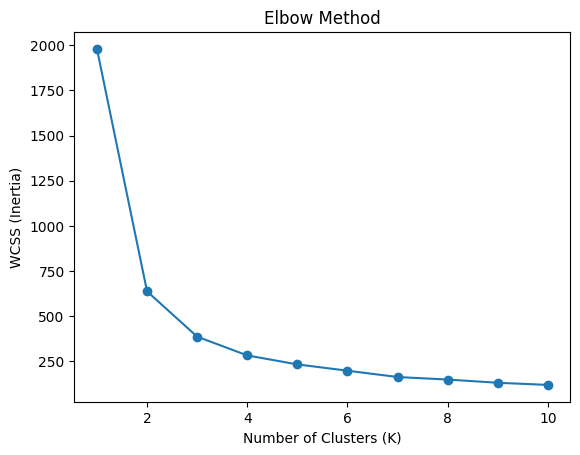

In [27]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# clean df
df_clean = df.dropna(subset=['Annual Income (k$)', 'Spending Score (1-100)'])

# features
X = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']]

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# kmeans
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# add cluster column
df_clean['Cluster'] = clusters

df_clean.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,2
1,1001,M,34.0,48.4,37.0,2
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,1


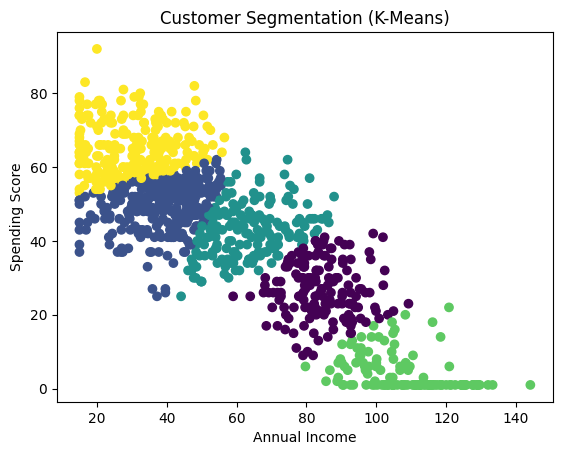

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['Annual Income (k$)'],
            df_clean['Spending Score (1-100)'],
            c=df_clean['Cluster'])

plt.title("Customer Segmentation (K-Means)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [5]:
centroids = kmeans.cluster_centers_
print("Centroids:\n", centroids)

Centroids:
 [[ 9.50444003e-01 -7.92509555e-01]
 [-6.40457026e-01  3.40750430e-01]
 [ 2.08967540e-01  1.33585628e-03]
 [ 1.77036072e+00 -1.90585470e+00]
 [-9.27681759e-01  1.11436921e+00]]


In [6]:
df_clean.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,84.391026,26.814103
1,38.771572,49.548495
2,63.151977,42.723164
3,107.915079,4.412698
4,30.760345,65.155172


In [7]:
cluster_names = {
    0: "Budget Customers",
    1: "Regular Customers",
    2: "High Income Low Spending",
    3: "VIP Customers",
    4: "Low Income High Spending"
}

df_clean['Segment'] = df_clean['Cluster'].map(cluster_names)
df_clean.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1000,M,39.0,59.9,58.0,2,High Income Low Spending
1,1001,M,34.0,48.4,37.0,2,High Income Low Spending
2,1002,F,40.0,70.5,26.0,0,Budget Customers
3,1003,F,47.0,81.1,30.0,0,Budget Customers
4,1004,F,33.0,42.1,58.0,1,Regular Customers


In [8]:
#final model file 
df_clean.to_csv("segmented_customers.csv", index=False)
print("File saved successfully!")

File saved successfully!


In [9]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved!")

Model and scaler saved!
